In [189]:
import numpy as np
import matplotlib.pyplot as plt
from vedo import *
import random
import matplotlib.patches as patches

In [191]:
# template

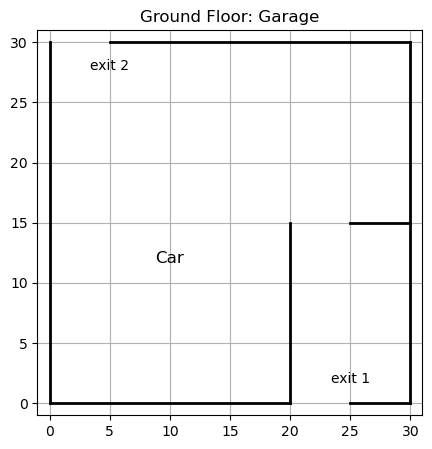

In [193]:
walls_ground = [
    ((0,0), (20,0)),
    ((25,0),(30,0)),
    ((30,0), (30,30)),   
    ((5,30),(30,30)),   
    ((0,30), (0,0)),     

    #hallway
    ((20,0), (20,15)),
    ((25,15),(30,15)),

]

def plot_walls(walls, exits=None, title="Floor Plan"):
    plt.figure(figsize=(10, 5))

    for wall in walls:
        A, B = wall
        x_values = [A[0], B[0]]
        y_values = [A[1], B[1]]
        plt.plot(x_values, y_values, 'k-', linewidth=2)

    # label garage
    plt.text(10, 12, "Car", fontsize=12, ha='center', va='center')
    plt.text(25, 2, "exit 1", fontsize=10, ha='center', va='center')
    plt.text(5, 28, "exit 2", fontsize=10, ha='center', va='center')

    plt.xlim(-1, 31)
    plt.ylim(-1, 31)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_walls(walls_ground, title="Ground Floor: Garage")

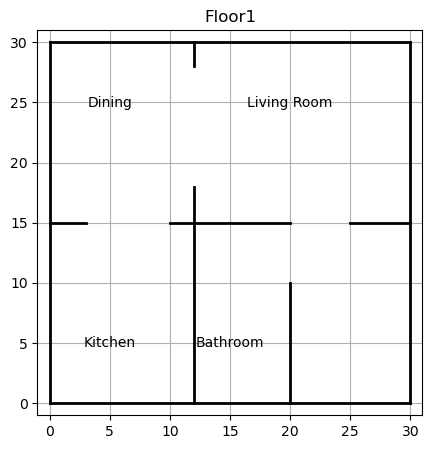

In [137]:
walls_Floor1 = [
    ((0,0), (30,0)),     
    ((30,0), (30,30)),   
    ((30,30), (0,30)),   
    ((0,30), (0,0)),
    ((0,15),(3,15)),
    ((10,15),(12,15)),
    
     #hallway
    ((20,0), (20,10)),
    ((25,15),(30,15)),

    
    #inner walls
    ((12,30),(12,28)),
    ((12,0),(12,18)),
    ((12,15),(20,15)),


]
def plot_walls(walls, title="Floor Plan"):
    plt.figure(figsize=(10,5))
    ax = plt.gca()

    for wall in walls:
        A, B = wall
        plt.plot([A[0], B[0]], [A[1], B[1]], 'k-', linewidth=2)

    # label
    plt.text(20,25,"Living Room",fontsize=10, ha='center',va='center')
    plt.text(15,5,"Bathroom",fontsize=10, ha='center',va='center')
    plt.text(5,25,"Dining",fontsize=10, ha='center',va='center')
    plt.text(5,5,"Kitchen",fontsize=10, ha='center',va='center')
    

    plt.xlim(-1,31)
    plt.ylim(-1,31)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.grid(True)

    plt.show()

plot_walls(walls_Floor1, title="Floor1")

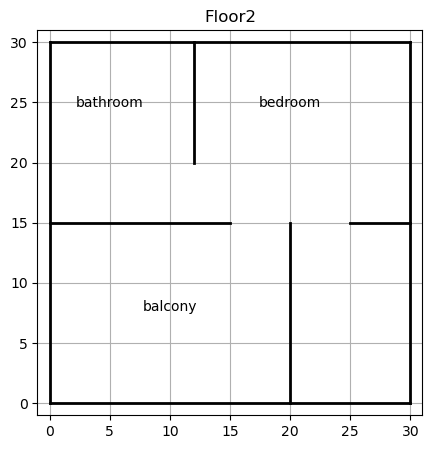

In [139]:
walls_Floor2 = [
    ((0,0), (30,0)),     
    ((30,0), (30,30)),   
    ((30,30), (0,30)),   
    ((0,30), (0,0)),
    
      #hallway
    ((20,0), (20,15)),
    ((25,15),(30,15)),


    #inner walls
    ((0,15),(15,15)),
    ((12,20),(12,30)),

]
def plot_walls(walls, title="Floor Plan"):
    plt.figure(figsize=(10,5))
    ax = plt.gca()

    for wall in walls:
        A, B = wall
        plt.plot([A[0], B[0]], [A[1], B[1]], 'k-', linewidth=2)

    # label
    plt.text(20,25,"bedroom",fontsize=10, ha='center',va='center')
    plt.text(5,25,"bathroom",fontsize=10, ha='center',va='center')
    plt.text(10,8,"balcony",fontsize=10, ha='center',va='center')

    plt.xlim(-1,31)
    plt.ylim(-1,31)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.grid(True)

    plt.show()

plot_walls(walls_Floor2, title="Floor2")

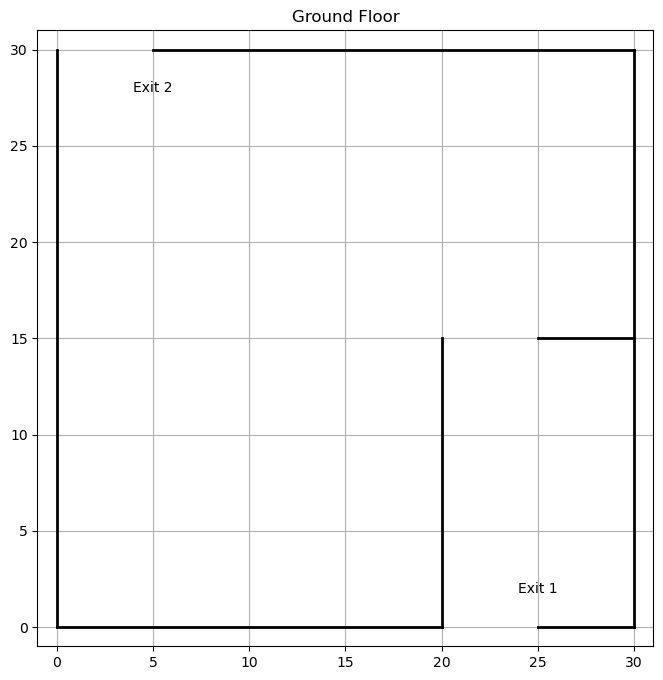

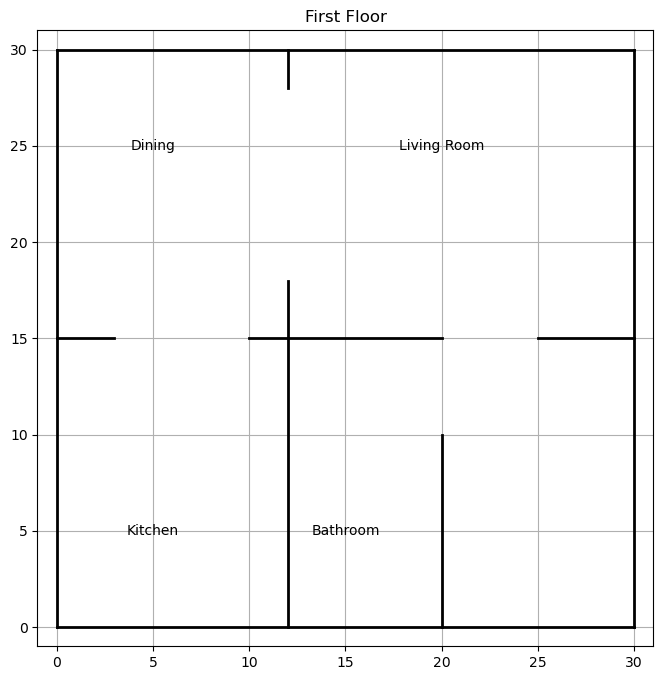

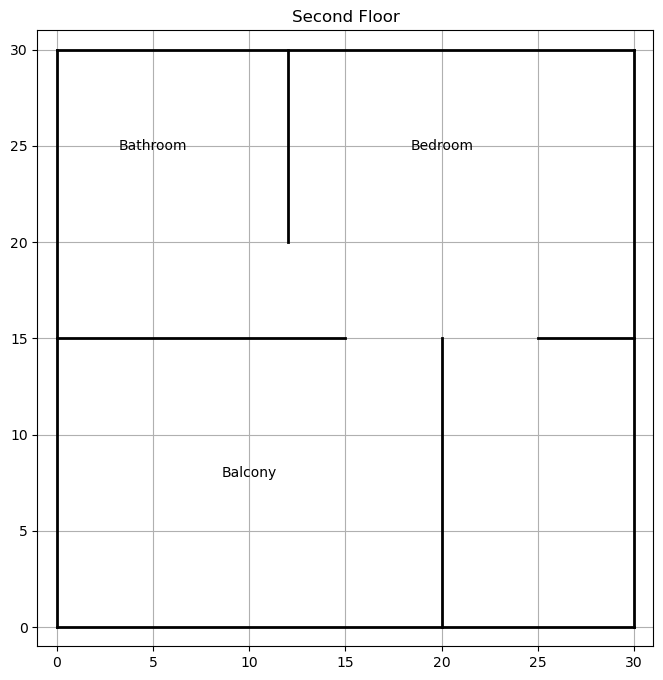

In [195]:
# converting for simulation use
def plot_walls(walls, labels=None, title="Floor Plan"):
    plt.figure(figsize=(8,8))

    for A, B in walls:
        plt.plot([A[0], B[0]], [A[1], B[1]], 'k-', linewidth=2)

    if labels:
        for x, y, text in labels:
            plt.text(x, y, text, fontsize=10, ha='center', va='center')

    plt.xlim(-1, 31)
    plt.ylim(-1, 31)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.grid(True)
    plt.show()

labels_ground = [
    (25, 2, "Exit 1"),
    (5, 28, "Exit 2"),
]

labels_floor1 = [
    (20,25,"Living Room"),
    (15,5,"Bathroom"),
    (5,25,"Dining"),
    (5,5,"Kitchen"),
]

labels_floor2 = [
    (20,25,"Bedroom"),
    (5,25,"Bathroom"),
    (10,8,"Balcony"),
]
plot_walls(walls_ground, labels_ground, "Ground Floor")
plot_walls(walls_Floor1, labels_floor1, "First Floor")
plot_walls(walls_Floor2, labels_floor2, "Second Floor")

In [145]:
# -----------------------------
# BASIC HEIGHTS
# -----------------------------
H = 8.0
z_ground = 0.0
z_first = H
z_second = 2 * H
    return [wall1, wall2, top]def make_floor_walls(walls, z):
    objs = []
    for A, B in walls:
        objs.append(make_wall_segment(A, B, z))
    return objs


In [295]:
# ============================================================
# EVACUATION SIMULATION - ALL IN ONE CELL (ROOM-ADAPTED)
# ============================================================
import numpy as np
import random
from vedo import *

settings.default_backend = "vtk"

# -----------------------------
# BASIC SETTINGS
# -----------------------------
np.random.seed(7)
random.seed(7)

H = 8.0
z_ground = 0.0
z_first = H
z_second = 2 * H

xmin, xmax = 0.0, 30.0
ymin, ymax = 0.0, 30.0

# -----------------------------
# WALL LISTS
# -----------------------------
walls_ground = [
    ((0,0), (20,0)),
    ((25,0),(30,0)),
    ((30,0), (30,30)),
    ((5,30),(30,30)),
    ((0,30), (0,0)),

    # hallway
    ((25,15),(30,15)),
]

walls_Floor1 = [
    ((0,0), (30,0)),
    ((30,0), (30,30)),
    ((30,30), (0,30)),
    ((0,30), (0,0)),
    ((0,15),(3,15)),
    ((10,15),(12,15)),

    # hallway
    ((20,0), (20,10)),
    ((25,15),(30,15)),

    # inner walls
    ((12,30),(12,28)),
    ((12,0),(12,18)),
    ((12,15),(20,15)),
]

walls_Floor2 = [
    ((0,0), (30,0)),
    ((30,0), (30,30)),
    ((30,30), (0,30)),
    ((0,30), (0,0)),

    # hallway
    ((20,0), (20,15)),
    ((25,15),(30,15)),

    # inner walls
    ((0,15),(15,15)),
    ((12,20),(12,30)),
]

# -----------------------------
# EXITS
# -----------------------------
exits = np.array([
    [25.0, 2.0, z_ground],
    [5.0, 28.0, z_ground]
], dtype=float)

exit_tolerance = 2.0

# -----------------------------
# GROUND FLOOR WAYPOINTS
# -----------------------------
ground_waypoints = {
    "hall_inner": np.array([22.5, 12.0, z_ground], dtype=float),
    "hall_bottom_exit": np.array([24.5, 4.0, z_ground], dtype=float),
    "left_upper_exit": np.array([5.0, 28.0, z_ground], dtype=float),
}

# -----------------------------
# RAMPS
# A -> B is ascending
# -----------------------------
ramps = [
    {
        "name": "ground_to_first",
        "A": np.array([28.0, 5.0], dtype=float),
        "B": np.array([28.0, 10.0], dtype=float),
        "r": 1.5,
        "z0": z_ground,
        "z1": z_first
    },
    {
        "name": "first_to_second",
        "A": np.array([25.0, 18.0], dtype=float),
        "B": np.array([25.0, 24.0], dtype=float),
        "r": 1.5,
        "z0": z_first,
        "z1": z_second
    },
    {
        "name": "ground_to_first_left",
        "A": np.array([8.0, 25.0], dtype=float),
        "B": np.array([8.0, 20.0], dtype=float),
        "r": 1.5,
        "z0": z_ground,
        "z1": z_first
    },
    {
        "name": "first_to_second_left",
        "A": np.array([2.0, 22.0], dtype=float),
        "B": np.array([2.0, 27.0], dtype=float),
        "r": 1.5,
        "z0": z_first,
        "z1": z_second
    }
]

# -----------------------------
# SIMULATION PARAMETERS
# -----------------------------
num_agents = 20
max_steps = 700
max_z_step = 0.35

dt = 0.040
momentum_beta = 0.60
max_step_norm = 0.20

tau = 0.9

w_goal = 1.6
w_height = 140.0
w_wall = 1.0
w_repulsion = 1.6
w_smooth = 0.14
w_ramp = 2.0
w_waypoint = 2.0
w_ramp_progress = 2

wall_sigma = 0.28
wall_influence_radius = 1.0

repulsion_sigma = 0.9
repulsion_radius = 1.10

fd_eps = 0.025
agent_radius = 0.36

# spawn settings
spawn_wall_clearance = 1.0
spawn_agent_clearance = 1.0

# ramp handling
ramp_surface_pad = 0.20
ramp_collision_relax = 0.18
ramp_release_u = 0.14
ramp_release_z_tol = 0.55

# -----------------------------
# GEOMETRY HELPERS
# -----------------------------
def clamp(v, lo, hi):
    return max(lo, min(hi, v))
    
def clamp_vertical_move(z_old, z_target, max_dz):
    dz = z_target - z_old
    if dz > max_dz:
        return z_old + max_dz
    if dz < -max_dz:
        return z_old - max_dz
    return z_target

def point_to_segment_distance_2d(P, A, B):
    P = np.asarray(P, dtype=float)
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    AB = B - A
    denom = np.dot(AB, AB)
    if denom == 0:
        return np.linalg.norm(P - A)

    t = np.dot(P - A, AB) / denom
    t = np.clip(t, 0.0, 1.0)
    Q = A + t * AB
    return np.linalg.norm(P - Q)

def ramp_u(x, y, ramp):
    A = ramp["A"]
    B = ramp["B"]
    v = B - A
    denom = np.dot(v, v)
    if denom == 0:
        return 0.0
    P = np.array([x, y], dtype=float)
    t = np.dot(P - A, v) / denom
    return np.clip(t, 0.0, 1.0)

def point_in_ramp_footprint(x, y, ramp, extra=0.0):
    P = np.array([x, y], dtype=float)
    return point_to_segment_distance_2d(P, ramp["A"], ramp["B"]) <= (ramp["r"] + extra)

def z_ramp(x, y, ramp):
    u = ramp_u(x, y, ramp)
    return ramp["z0"] + (ramp["z1"] - ramp["z0"]) * u

def nearest_flat_floor_z(z):
    floors = np.array([z_ground, z_first, z_second], dtype=float)
    idx = np.argmin(np.abs(floors - z))
    return floors[idx]

def floor_index_from_z(z):
    floors = np.array([z_ground, z_first, z_second], dtype=float)
    idx = np.argmin(np.abs(floors - z))
    return int(idx)

def floor_z_from_index(idx):
    return [z_ground, z_first, z_second][idx]

def inside_bounds(x, y):
    return (xmin <= x <= xmax) and (ymin <= y <= ymax)

def point_hits_wall_band(x, y, walls, band=0.18):
    P = np.array([x, y], dtype=float)
    for A, B in walls:
        if point_to_segment_distance_2d(P, A, B) <= band:
            return True
    return False

def floor_walls_from_z(z):
    idx = floor_index_from_z(z)
    if idx == 0:
        return walls_ground
    elif idx == 1:
        return walls_Floor1
    return walls_Floor2

def down_ramps_from_floor(z_floor):
    out = []
    for ramp in ramps:
        if abs(ramp["z1"] - z_floor) < 1e-8 and ramp["z0"] < ramp["z1"]:
            out.append(ramp)
    return out

def on_any_ramp_xy(x, y, extra=0.0):
    for ramp in ramps:
        if point_in_ramp_footprint(x, y, ramp, extra=extra):
            return True
    return False

def current_ramp(x, y, z, extra=0.0):
    best = None
    best_score = 1e18

    for ramp in ramps:
        if not point_in_ramp_footprint(x, y, ramp, extra=extra):
            continue

        z_center = z - agent_radius
        zmin = min(ramp["z0"], ramp["z1"]) - 0.55
        zmax = max(ramp["z0"], ramp["z1"]) + 0.55
        if not (zmin <= z_center <= zmax):
            continue

        u = ramp_u(x, y, ramp)

        # Release agents from ramp mode near the lower end
        if u < ramp_release_u and abs(z_center - ramp["z0"]) < ramp_release_z_tol:
            continue

        dxy = point_to_segment_distance_2d((x, y), ramp["A"], ramp["B"])
        zr = z_ramp(x, y, ramp)
        score = dxy + 0.20 * abs(z_center - zr)

        if score < best_score:
            best_score = score
            best = ramp

    return best

def z_surface(x, y, z_current):
    z_flat = nearest_flat_floor_z(z_current)
    best = None
    best_score = 1e18

    for ramp in ramps:
        if not point_in_ramp_footprint(x, y, ramp, extra=ramp_surface_pad):
            continue

        zr = z_ramp(x, y, ramp)

        # only allow the ramp surface if agent is actually near that ramp's vertical span
        zmin = min(ramp["z0"], ramp["z1"]) - 0.45
        zmax = max(ramp["z0"], ramp["z1"]) + 0.45
        if not (zmin <= z_current <= zmax):
            continue

        dxy = point_to_segment_distance_2d((x, y), ramp["A"], ramp["B"])
        score = dxy + 0.25 * abs(z_current - zr)

        if score < best_score:
            best_score = score
            best = ramp

    if best is not None:
        return z_ramp(x, y, best)

    return z_flat

def reached_exit(p):
    if floor_index_from_z(p[2]) != 0:
        return False
    dists_xy = np.linalg.norm(exits[:, :2] - p[None, :2], axis=1)
    return np.min(dists_xy) < exit_tolerance

# -----------------------------
# SEGMENT INTERSECTION
# -----------------------------
def orient(a, b, c):
    return (b[0]-a[0])*(c[1]-a[1]) - (b[1]-a[1])*(c[0]-a[0])

def on_segment(a, b, c):
    return (
        min(a[0], b[0]) - 1e-9 <= c[0] <= max(a[0], b[0]) + 1e-9 and
        min(a[1], b[1]) - 1e-9 <= c[1] <= max(a[1], b[1]) + 1e-9
    )

def segments_intersect(p1, p2, q1, q2):
    o1 = orient(p1, p2, q1)
    o2 = orient(p1, p2, q2)
    o3 = orient(q1, q2, p1)
    o4 = orient(q1, q2, p2)

    if (o1 * o2 < 0) and (o3 * o4 < 0):
        return True

    if abs(o1) < 1e-9 and on_segment(p1, p2, q1): return True
    if abs(o2) < 1e-9 and on_segment(p1, p2, q2): return True
    if abs(o3) < 1e-9 and on_segment(q1, q2, p1): return True
    if abs(o4) < 1e-9 and on_segment(q1, q2, p2): return True

    return False

def path_crosses_wall(p_old, p_new, walls):
    a = (float(p_old[0]), float(p_old[1]))
    b = (float(p_new[0]), float(p_new[1]))
    for A, B in walls:
        if segments_intersect(a, b, A, B):
            return True
    return False

# -----------------------------
# COST TERMS
# -----------------------------
def stable_softmin(vals, tau):
    vals = np.asarray(vals, dtype=float)
    m = np.min(vals)
    shifted = vals - m
    s = np.sum(np.exp(-shifted / tau))
    if s <= 1e-12 or not np.isfinite(s):
        return float(m)
    out = m - tau * np.log(s)
    if not np.isfinite(out):
        return float(m)
    return float(out)

def ramp_descend_anchor(ramp):
    return np.array([ramp["B"][0], ramp["B"][1], ramp["z1"]], dtype=float)

def ramp_lower_target(ramp):
    return np.array([ramp["A"][0], ramp["A"][1], ramp["z0"]], dtype=float)

def choose_ground_exit_and_waypoint(p):
    x, y, _ = p

    d_exit0 = np.linalg.norm(p[:2] - exits[0][:2])
    d_exit1 = np.linalg.norm(p[:2] - exits[1][:2])

    score0 = d_exit0
    score1 = d_exit1

    if x < 14.0:
        score1 -= 2.0
    if y > 18.0:
        score1 -= 2.0

    if score1 < score0:
        return exits[1], ground_waypoints["left_upper_exit"]
    else:
        return exits[0], ground_waypoints["hall_bottom_exit"]

def ground_navigation_target(p):
    chosen_exit, near_exit_wp = choose_ground_exit_and_waypoint(p)
    hall_inner = ground_waypoints["hall_inner"]

    if np.linalg.norm(p[:2] - hall_inner[:2]) > 3.0 and 10.0 < p[0] < 21.0 and p[1] < 20.0:
        return hall_inner

    if np.linalg.norm(p[:2] - near_exit_wp[:2]) > 2.0:
        return near_exit_wp

    return chosen_exit

def cost_goal(p):
    z = p[2]

    ramp_here = current_ramp(p[0], p[1], z, extra=0.12)
    if ramp_here is not None:
        tgt = ramp_lower_target(ramp_here)
        return np.sum((p - tgt)**2)

    floor_idx = floor_index_from_z(z)
    z_floor = floor_z_from_index(floor_idx)

    if floor_idx == 0:
        target = ground_navigation_target(p)
        return np.sum((p - target)**2)

    downs = down_ramps_from_floor(z_floor)
    if len(downs) == 0:
        return 0.0

    candidates = np.array([ramp_descend_anchor(r) for r in downs], dtype=float)
    cvals = np.sum((candidates - p[None, :])**2, axis=1)
    return stable_softmin(cvals, tau)

def cost_height(p):
    zsurf = z_surface(p[0], p[1], p[2] - agent_radius) + agent_radius
    return w_height * (p[2] - zsurf)**2

def cost_walls(p):
    x, y, z = p
    walls = floor_walls_from_z(z)
    total = 0.0

    boundary_clearance = 0.55
    boundary_gain = 28.0

    d_left   = x - xmin
    d_right  = xmax - x
    d_bottom = y - ymin
    d_top    = ymax - y

    for d in [d_left, d_right, d_bottom, d_top]:
        if d < boundary_clearance:
            total += boundary_gain / (d + 1e-3)**2

    wall_clearance = 0.52
    wall_gain = 55.0

    if current_ramp(x, y, z, extra=0.20) is not None:
        wall_clearance = 0.34
        wall_gain = 18.0

    for A, B in walls:
        d = point_to_segment_distance_2d((x, y), A, B)
        if d < wall_clearance:
            total += wall_gain / (d + 1e-3)**2
        elif d < wall_influence_radius:
            total += 5.0 * np.exp(-((d - wall_clearance) / wall_sigma)**2)

    return w_wall * total

def cost_ramps(p):
    z = p[2]
    if current_ramp(p[0], p[1], z, extra=0.12) is not None:
        return 0.0

    floor_idx = floor_index_from_z(z)
    if floor_idx == 0:
        return 0.0

    z_floor = floor_z_from_index(floor_idx)
    downs = down_ramps_from_floor(z_floor)
    if len(downs) == 0:
        return 0.0

    P = np.array([p[0], p[1]], dtype=float)
    vals = []
    for ramp in downs:
        d = point_to_segment_distance_2d(P, ramp["A"], ramp["B"])
        vals.append(d**2)

    return stable_softmin(vals, tau)

def cost_ramp_progress(p):
    ramp_here = current_ramp(p[0], p[1], p[2], extra=0.12)
    if ramp_here is None:
        return 0.0

    u = ramp_u(p[0], p[1], ramp_here)
    return w_ramp_progress * (u**2)

def cost_waypoint_bias(p):
    if floor_index_from_z(p[2]) != 0:
        return 0.0
    tgt = ground_navigation_target(p)
    return w_waypoint * np.sum((p - tgt)**2)

def cost_repulsion(i, p, agents):
    total = 0.0

    on_ramp = current_ramp(p[0], p[1], p[2], extra=0.12) is not None
    local_repulsion_weight = w_repulsion * (0.05 if on_ramp else 1.0)

    for j, q in enumerate(agents):
        if i == j:
            continue

        dxy = np.linalg.norm(p[:2] - q[:2])
        dz = abs(p[2] - q[2])

        if dz > 1.2 * H:
            continue

        if dxy < repulsion_radius:
            total += np.exp(-((dxy + 1e-6) / repulsion_sigma)**2) / (dxy + 1e-3)

    return local_repulsion_weight * total

def cost_smooth(p, p_prev):
    return w_smooth * np.sum((p - p_prev)**2)

def total_cost_for_agent(i, p, agents, prev_positions):
    val = (
        w_goal * cost_goal(p)
        + cost_waypoint_bias(p)
        + cost_height(p)
        + cost_walls(p)
        + w_ramp * cost_ramps(p)
        + cost_ramp_progress(p)
        + cost_repulsion(i, p, agents)
        + cost_smooth(p, prev_positions[i])
    )

    if not np.isfinite(val):
        return 1e12
    return val

# -----------------------------
# NUMERICAL GRADIENT
# -----------------------------
def finite_difference_gradient(i, p, agents, prev_positions, eps=fd_eps):
    grad = np.zeros(3, dtype=float)

    for k in range(3):
        step = np.zeros(3, dtype=float)
        step[k] = eps

        c_plus = total_cost_for_agent(i, p + step, agents, prev_positions)
        c_minus = total_cost_for_agent(i, p - step, agents, prev_positions)

        if not np.isfinite(c_plus):
            c_plus = 1e12
        if not np.isfinite(c_minus):
            c_minus = 1e12

        grad[k] = (c_plus - c_minus) / (2 * eps)

    grad = np.nan_to_num(grad, nan=0.0, posinf=1e6, neginf=-1e6)
    return grad

# -----------------------------
# RANDOM AGENT INITIALIZATION
# -----------------------------
def random_agent_position(existing_agents=None):
    if existing_agents is None:
        existing_agents = []

    floors = [z_ground, z_first, z_second]
    z0 = random.choice(floors)

    for _ in range(3000):
        x = random.uniform(2.0, 28.0)
        y = random.uniform(2.0, 28.0)

        if z0 == z_ground:
            walls = walls_ground
        elif z0 == z_first:
            walls = walls_Floor1
        else:
            walls = walls_Floor2

        if point_hits_wall_band(x, y, walls, band=spawn_wall_clearance):
            continue

        if on_any_ramp_xy(x, y, extra=0.20):
            continue

        z = z_surface(x, y, z0) + agent_radius
        candidate = np.array([x, y, z], dtype=float)

        too_close = False
        for q in existing_agents:
            same_floor = floor_index_from_z(q[2]) == floor_index_from_z(candidate[2])
            if same_floor and np.linalg.norm(candidate[:2] - q[:2]) < spawn_agent_clearance:
                too_close = True
                break

        if too_close:
            continue

        return candidate

    return np.array([10.0, 10.0, z0 + agent_radius], dtype=float)

agents_list = []
for _ in range(num_agents):
    agents_list.append(random_agent_position(agents_list))

agents = np.array(agents_list, dtype=float)
prev_positions = agents.copy()
velocities = np.zeros_like(agents)
active = np.ones(num_agents, dtype=bool)

# -----------------------------
# 3D SCENE HELPERS
# -----------------------------
def make_floor_plate(z, color="lightgray", alpha=0.20):
    pts = [(0,0,z), (30,0,z), (30,30,z), (0,30,z)]
    faces = [[0,1,2,3]]
    return Mesh([pts, faces]).c(color).alpha(alpha)

def make_wall_segment(A, B, z, height=3.0, thickness=0.06, color="gray", alpha=0.22):
    x1, y1 = A
    x2, y2 = B

    dx, dy = x2 - x1, y2 - y1
    L = np.hypot(dx, dy)
    if L < 1e-9:
        return None

    nx, ny = -dy / L, dx / L
    ox, oy = 0.5 * thickness * nx, 0.5 * thickness * ny

    pts = [
        (x1 - ox, y1 - oy, z),
        (x2 - ox, y2 - oy, z),
        (x2 + ox, y2 + oy, z),
        (x1 + ox, y1 + oy, z),
        (x1 - ox, y1 - oy, z + height),
        (x2 - ox, y2 - oy, z + height),
        (x2 + ox, y2 + oy, z + height),
        (x1 + ox, y1 + oy, z + height),
    ]
    faces = [
        [0,1,2,3],
        [4,5,6,7],
        [0,1,5,4],
        [1,2,6,5],
        [2,3,7,6],
        [3,0,4,7],
    ]
    return Mesh([pts, faces]).c(color).alpha(alpha)

def make_floor_walls(walls, z, height=3.0, color="gray", alpha=0.22):
    objs = []
    for A, B in walls:
        w = make_wall_segment(A, B, z, height=height, color=color, alpha=alpha)
        if w is not None:
            objs.append(w)
    return objs

def make_ramp_mesh(ramp, n_along=18, n_across=6, color="orange", alpha=0.55):
    A = ramp["A"]
    B = ramp["B"]
    width = ramp["r"]

    v = B - A
    L = np.linalg.norm(v)
    if L == 0:
        return None

    vhat = v / L
    nhat = np.array([-vhat[1], vhat[0]])

    pts = []
    faces = []

    for i in range(n_along + 1):
        u = i / n_along
        center = A + u * v
        z = ramp["z0"] + (ramp["z1"] - ramp["z0"]) * u

        for j in range(n_across + 1):
            s = -width + (2 * width) * j / n_across
            xy = center + s * nhat
            pts.append([xy[0], xy[1], z])

    def idx(i, j):
        return i * (n_across + 1) + j

    for i in range(n_along):
        for j in range(n_across):
            faces.append([idx(i, j), idx(i+1, j), idx(i+1, j+1), idx(i, j+1)])

    return Mesh([pts, faces]).c(color).alpha(alpha)

# -----------------------------
# BUILD STATIC SCENE
# -----------------------------
scene = []

scene.append(make_floor_plate(z_ground, color="lightblue", alpha=0.30))
scene.append(make_floor_plate(z_first,  color="lightgreen", alpha=0.18))
scene.append(make_floor_plate(z_second, color="plum", alpha=0.16))

scene += make_floor_walls(walls_ground, z_ground, height=3.6, color="gray", alpha=0.22)
scene += make_floor_walls(walls_Floor1, z_first,  height=3.2, color="gray", alpha=0.22)
scene += make_floor_walls(walls_Floor2, z_second, height=3.2, color="gray", alpha=0.22)

for ramp in ramps:
    rm = make_ramp_mesh(ramp)
    if rm is not None:
        scene.append(rm)

for e in exits:
    scene.append(Sphere(pos=e + np.array([0,0,0.35]), r=0.42).c("green").lighting("off"))

scene.append(Sphere(pos=ground_waypoints["hall_inner"] + np.array([0,0,0.25]), r=0.22).c("blue").lighting("off"))
scene.append(Sphere(pos=ground_waypoints["hall_bottom_exit"] + np.array([0,0,0.25]), r=0.22).c("cyan").lighting("off"))
scene.append(Sphere(pos=ground_waypoints["left_upper_exit"] + np.array([0,0,0.25]), r=0.22).c("cyan").lighting("off"))

scene.append(Text3D("Ground", pos=(1, 1, z_ground + 0.35), s=0.4, c="black"))
scene.append(Text3D("First",  pos=(1, 1, z_first + 0.35),  s=0.4, c="black"))
scene.append(Text3D("Second", pos=(1, 1, z_second + 0.35), s=0.4, c="black"))

agent_spheres = []
for p in agents:
    s = Sphere(pos=p, r=agent_radius).c("red5").lighting("off")
    agent_spheres.append(s)
    scene.append(s)

# -----------------------------
# MAIN SIMULATION LOOP
# -----------------------------
plt = Plotter(size=(1200, 900), bg="white")

cam = dict(
    pos=(58, -52, 42),
    focal_point=(15, 15, 7),
    viewup=(0, 0, 1),
    distance=85
)

plt.show(*scene, axes=1, camera=cam, interactive=False)

for step in range(max_steps):
    old_agents = agents.copy()

    for i in range(num_agents):
        if not active[i]:
            continue

        p = agents[i].copy()

        grad = finite_difference_gradient(i, p, agents, prev_positions)

        velocities[i] = momentum_beta * velocities[i] - dt * grad

        if not np.all(np.isfinite(velocities[i])):
            velocities[i] = np.zeros(3, dtype=float)

        on_ramp_now = current_ramp(p[0], p[1], p[2], extra=0.12) is not None
        local_step_cap = max_step_norm * (1.25 if on_ramp_now else 1.0)

        step_norm = np.linalg.norm(velocities[i])
        if step_norm > local_step_cap:
            velocities[i] *= local_step_cap / step_norm

        p_trial = p + velocities[i]

        p_trial[0] = clamp(p_trial[0], xmin + 0.22, xmax - 0.22)
        p_trial[1] = clamp(p_trial[1], ymin + 0.22, ymax - 0.22)
        z_target = z_surface(p_trial[0], p_trial[1], p[2] - agent_radius) + agent_radius
        p_trial[2] = clamp_vertical_move(p[2], z_target, max_z_step)

        walls_here = floor_walls_from_z(p_trial[2])

        collision_band = 0.42
        if current_ramp(p[0], p[1], p[2], extra=0.20) is not None or current_ramp(p_trial[0], p_trial[1], p_trial[2], extra=0.20) is not None:
            collision_band = ramp_collision_relax

        if path_crosses_wall(p, p_trial, walls_here) or point_hits_wall_band(p_trial[0], p_trial[1], walls_here, band=collision_band):
            velocities[i] *= 0.25
            p_trial = p + velocities[i]
            p_trial[0] = clamp(p_trial[0], xmin + 0.22, xmax - 0.22)
            p_trial[1] = clamp(p_trial[1], ymin + 0.22, ymax - 0.22)
            z_target = z_surface(p_trial[0], p_trial[1], p[2] - agent_radius) + agent_radius
            p_trial[2] = clamp_vertical_move(p[2], z_target, max_z_step)

            if path_crosses_wall(p, p_trial, walls_here) or point_hits_wall_band(p_trial[0], p_trial[1], walls_here, band=collision_band):
                p_trial = p.copy()
                velocities[i] = np.zeros(3, dtype=float)

        if not np.all(np.isfinite(p_trial)):
            p_trial = p.copy()
            velocities[i] = np.zeros(3, dtype=float)

        agents[i] = p_trial

        if reached_exit(agents[i]):
            active[i] = False
            velocities[i] = np.zeros(3, dtype=float)
            agent_spheres[i].alpha(0.0)
            continue

    prev_positions = old_agents.copy()

    for i in range(num_agents):
        agent_spheres[i].pos(agents[i])

    plt.render()

    if not np.any(active):
        print(f"All agents evacuated by step {step}.")
        break

print("Simulation finished.")
print("Evacuated:", np.sum(~active), "/", num_agents)
plt.interactive()

Simulation finished.
Evacuated: 15 / 20
